# 06 — Correlation Between Pageviews, Commits and Deadline Lag: Scatter Matrix

## What this notebook does

Explores whether there is a relationship between how actively students
browsed the newsfeed, how many commits they made, and how early or late
they submitted their work relative to deadlines.

## Data

- **Source:** `checking-logs.sqlite` → tables `checker`, `pageviews`, `deadlines`
- **Filtered:** only real students (`uid LIKE 'user_%'`), `project1` excluded
- **Aggregation:** per user — average deadline lag, total commits, total pageviews

## Key steps

1. Join `checker` with `deadlines` to calculate average lag per user
2. Join with `pageviews` to get total pageview count per user
3. Plot a scatter matrix with KDE on the diagonal for three variables:
   `avg_diff`, `pageviews`, `commits`

## Result

A scatter matrix showing pairwise relationships between the three metrics.
The only visible correlation is between **pageviews and commits** — students
who viewed the newsfeed more also tended to make more commits. No strong
correlation was found between deadline lag and the other two variables.

## Tools

`pandas` · `sqlite3` · `matplotlib`

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
avg_pageviews_commits = pd.io.sql.read_sql("""
                                       SELECT a.uid, a.avg_diff, a.commits, b.pageviews
                                       FROM (
                                       SELECT c.uid, AVG((strftime('%s', c.timestamp) - d.deadlines) / 3600) AS avg_diff, COUNT(c.timestamp) AS commits
                                       FROM checker AS c
                                       JOIN deadlines AS d ON c.labname = d.labs
                                       WHERE c.labname != 'project1'
                                       GROUP BY c.uid
                                       ) AS a
                                       JOIN (
                                       SELECT p.uid, COUNT(p.datetime) AS pageviews
                                       FROM pageviews AS p
                                       GROUP BY p.uid
                                       ) AS b ON a.uid = b.uid
                                       WHERE a.uid LIKE 'user_%'
                                       """,
                                       conn)
print(len(avg_pageviews_commits))
print(avg_pageviews_commits)

11
        uid    avg_diff  commits  pageviews
0    user_1  -58.000000       27         28
1   user_10  -92.266667       15         89
2   user_14 -193.693878       49        143
3   user_17  -48.325581       43         47
4   user_18   -4.600000        5          3
5   user_19  -46.815789      114         16
6   user_21  -84.000000       56         10
7   user_25  -46.509434       53        179
8   user_28  -40.297872       47        149
9    user_3 -105.000000       15        317
10  user_30  -59.107143       28          3


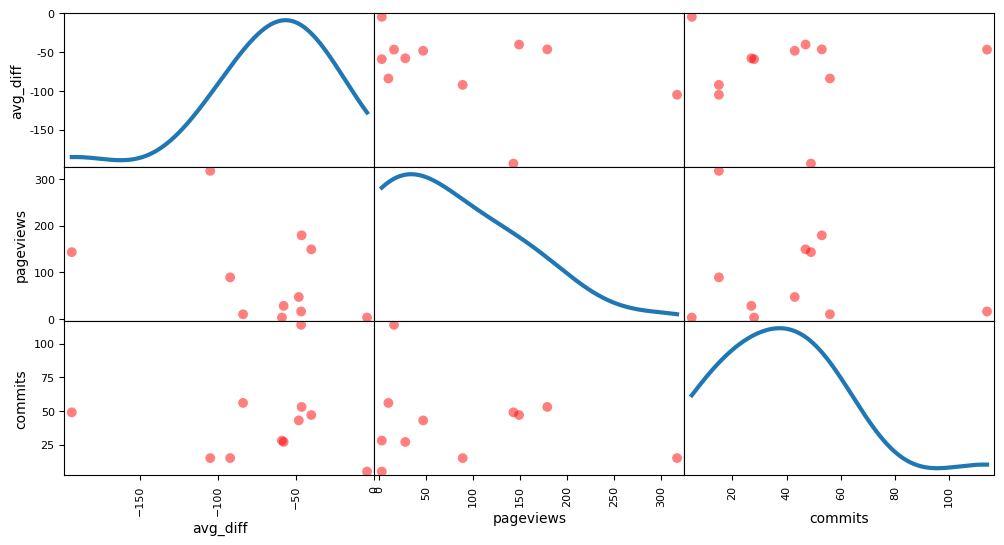

In [3]:
axes = scatter_matrix(avg_pageviews_commits[['avg_diff', 'pageviews', 'commits']], diagonal='kde', figsize=(12, 6), s=200, color="red")
for ax in axes.flatten():
    ax.get_lines()[0].set_linewidth(3) if ax.get_lines() else None

In [4]:
conn.close()